In [2]:
import os
import json
import time
import pickle
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



In [3]:
data_dir = Path("/home/mini/projects/review-intelligence-system/data/processed")

train_df = pd.read_parquet(data_dir / "train.parquet")
val_df = pd.read_parquet(data_dir / "val.parquet")
test_df = pd.read_parquet(data_dir / "test.parquet")

print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")

print(f"\nSentiment in train:")
print(train_df['sentiment'].value_counts())

Train: 71,216
Val:   8,902
Test:  8,903

Sentiment in train:
sentiment
positive    56296
negative     8454
neutral      6466
Name: count, dtype: int64


In [4]:
X_train = train_df['text_clean'].values
X_val = val_df['text_clean'].values
X_test = test_df['text_clean'].values

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['sentiment'])
y_val = label_encoder.transform(val_df['sentiment'])
y_test = label_encoder.transform(test_df['sentiment'])

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: {label}")

print(f"\nShapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val: {y_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test: {y_test.shape}")

Label mapping:
  0: negative
  1: neutral
  2: positive

Shapes:
  X_train: (71216,), y_train: (71216,)
  X_val:   (8902,), y_val: (8902,)
  X_test:  (8903,), y_test: (8903,)


In [5]:
def evaluate_model(
    y_true,
    y_pred,
    label_encoder,
    model_name: str,
    inference_time_ms: float = None,
    category_array: np.ndarray = None
) -> dict:
    """
    Comprehensive evaluation for sentiment classification.
    
    Returns:
        Dictionary with metrics for storage and comparison.
    """
    labels = label_encoder.classes_
    
    y_true_labels = label_encoder.inverse_transform(y_true)
    y_pred_labels = label_encoder.inverse_transform(y_pred)
    
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    f1_per_class = f1_score(y_true, y_pred, average=None)
    
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"F1 (macro):  {f1_macro:.4f}  (primary metric)")
    print(f"F1 (weighted): {f1_weighted:.4f}")
    if inference_time_ms is not None:
        print(f"Inference:   {inference_time_ms:.2f} ms/sample")
    
    print(f"\nPer-class breakdown:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 48)
    for i, label in enumerate(labels):
        print(f"{label:<12} {precision_per_class[i]:<12.4f} {recall_per_class[i]:<12.4f} {f1_per_class[i]:<12.4f}")
    
    category_metrics = {}
    if category_array is not None:
        print(f"\nPer-category macro F1:")
        for cat in np.unique(category_array):
            mask = category_array == cat
            if mask.sum() > 0:
                cat_f1 = f1_score(y_true[mask], y_pred[mask], average='macro', zero_division=0)
                category_metrics[cat] = cat_f1
                print(f"  {cat:<15}: {cat_f1:.4f}")
    
    results = {
        'model_name': model_name,
        'accuracy': float(accuracy),
        'f1_macro': float(f1_macro),
        'f1_weighted': float(f1_weighted),
        'f1_per_class': {labels[i]: float(f1_per_class[i]) for i in range(len(labels))},
        'precision_per_class': {labels[i]: float(precision_per_class[i]) for i in range(len(labels))},
        'recall_per_class': {labels[i]: float(recall_per_class[i]) for i in range(len(labels))},
        'inference_time_ms': inference_time_ms,
        'category_metrics': category_metrics
    }
    
    return results


def plot_confusion_matrix(y_true, y_pred, label_encoder, model_name: str, save_path: str = None):
    """Plot confusion matrix as heatmap."""
    labels = label_encoder.classes_
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'{model_name} — Confusion Matrix (Counts)', fontweight='bold')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[1], cbar_kws={'label': 'Proportion'})
    axes[1].set_title(f'{model_name} — Confusion Matrix (Normalized)', fontweight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()


print("Evaluation framework ready.")

Evaluation framework ready.


In [6]:
# Initialize TF-IDF vectorizer
# - max_features: vocabulary size limit (avoids memory blowup)
# - ngram_range: (1,2) means we use unigrams + bigrams
# - min_df: ignore words appearing in fewer than 2 documents (rare typos)
# - max_df: ignore words appearing in >95% docs (too common, low info)

print("Fitting TF-IDF vectorizer on train data...")
start = time.time()

tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,  # uses 1 + log(tf) instead of raw tf — better for text
    strip_accents='unicode',
    lowercase=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Done in {time.time() - start:.2f} seconds")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Train matrix shape: {X_train_tfidf.shape}")
print(f"Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")

Fitting TF-IDF vectorizer on train data...
Done in 18.25 seconds
Vocabulary size: 50,000
Train matrix shape: (71216, 50000)
Sparsity: 99.79%


In [7]:
print("Training Logistic Regression...")
start = time.time()

# class_weight='balanced' to handle class imbalance
# liblinear solver for large sparse data
# C=1.0 default regularization (we can tune later if needed)

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='liblinear',
    random_state=RANDOM_SEED,
    verbose=0
)

logreg.fit(X_train_tfidf, y_train)
training_time = time.time() - start
print(f"Training time: {training_time:.2f} seconds")

Training Logistic Regression...
Training time: 5.34 seconds


Predicting on validation set...

  TF-IDF + Logistic Regression (Validation)
Accuracy:    0.8603
F1 (macro):  0.6746  (primary metric)
F1 (weighted): 0.8568
Inference:   0.00 ms/sample

Per-class breakdown:
Class        Precision    Recall       F1          
------------------------------------------------
negative     0.6943       0.7048       0.6995      
neutral      0.4244       0.3614       0.3904      
positive     0.9272       0.9409       0.9340      

Per-category macro F1:
  Beauty         : 0.6637
  Books          : 0.6513
  Electronics    : 0.6674
Saved: ../reports/figures/05_logreg_confusion_val.png


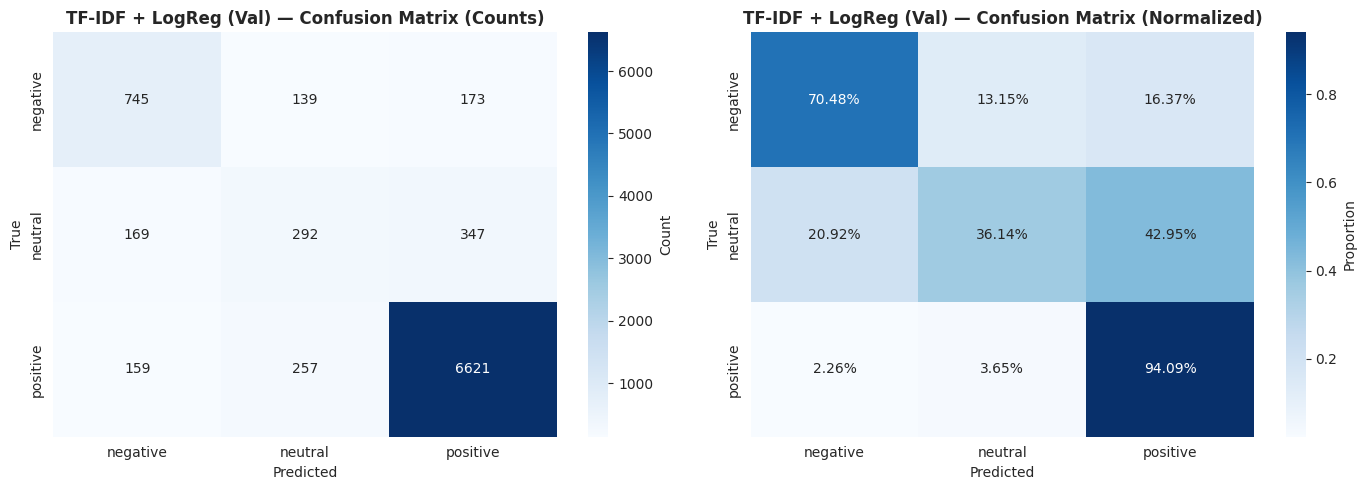

In [ ]:
print("Predicting on validation set...")
start = time.time()
y_val_pred_lr = logreg.predict(X_val_tfidf)
val_inference_time = (time.time() - start) / len(y_val) * 1000  # ms per sample

results_lr_val = evaluate_model(
    y_val, y_val_pred_lr, label_encoder,
    model_name="TF-IDF + Logistic Regression (Validation)",
    inference_time_ms=val_inference_time,
    category_array=val_df['category'].values
)

plot_confusion_matrix(
    y_val, y_val_pred_lr, label_encoder,
    model_name="TF-IDF + LogReg (Val)",
    save_path="../reports/figures/05_logreg_confusion_val.png"
)

Predicting on test set (held-out)...

  TF-IDF + Logistic Regression (Test)
Accuracy:    0.8523
F1 (macro):  0.6555  (primary metric)
F1 (weighted): 0.8483
Inference:   0.00 ms/sample

Per-class breakdown:
Class        Precision    Recall       F1          
------------------------------------------------
negative     0.6790       0.6604       0.6695      
neutral      0.3960       0.3412       0.3665      
positive     0.9214       0.9399       0.9306      

Per-category macro F1:
  Beauty         : 0.6555
  Books          : 0.6029
  Electronics    : 0.6527
Saved: ../reports/figures/06_logreg_confusion_test.png


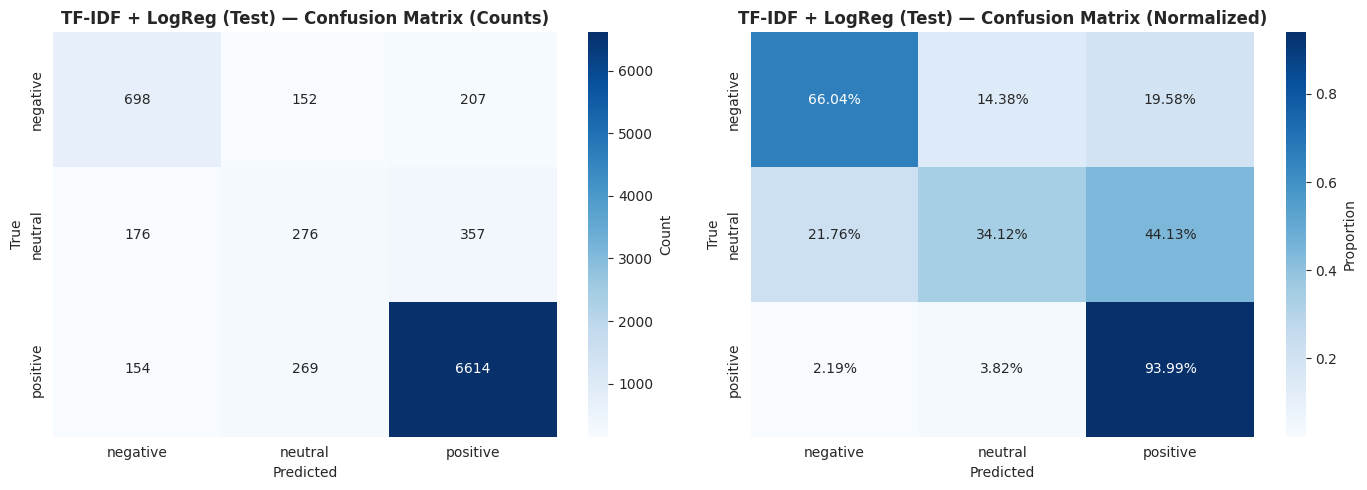

In [9]:
print("Predicting on test set (held-out)...")
start = time.time()
y_test_pred_lr = logreg.predict(X_test_tfidf)
test_inference_time = (time.time() - start) / len(y_test) * 1000

results_lr_test = evaluate_model(
    y_test, y_test_pred_lr, label_encoder,
    model_name="TF-IDF + Logistic Regression (Test)",
    inference_time_ms=test_inference_time,
    category_array=test_df['category'].values
)

plot_confusion_matrix(
    y_test, y_test_pred_lr, label_encoder,
    model_name="TF-IDF + LogReg (Test)",
    save_path="../reports/figures/06_logreg_confusion_test.png"
)

In [10]:
def show_top_features(vectorizer, model, label_encoder, top_n=15):
    """Show top features for each class."""
    feature_names = vectorizer.get_feature_names_out()
    
    for class_idx, class_name in enumerate(label_encoder.classes_):
        # For multi-class LogReg, model.coef_ has shape (n_classes, n_features)
        coefs = model.coef_[class_idx]
        
        # Top positive (most predictive of this class)
        top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
        top_features = [(feature_names[i], coefs[i]) for i in top_pos_idx]
        
        print(f"\nTop features for '{class_name}':")
        for feature, coef in top_features:
            print(f"  {coef:+.3f}  {feature}")


show_top_features(tfidf, logreg, label_encoder, top_n=15)


Top features for 'negative':
  +10.600  not
  +6.891  disappointed
  +6.505  useless
  +6.016  nothing
  +5.868  poor
  +5.805  not worth
  +5.555  horrible
  +5.534  waste
  +5.447  return
  +5.158  returned
  +5.044  at all
  +5.009  worst
  +4.994  very disappointed
  +4.965  returning
  +4.957  no

Top features for 'neutral':
  +8.129  but
  +7.529  however
  +6.375  three stars
  +6.204  ok
  +6.043  okay
  +5.640  not
  +4.045  unfortunately
  +3.880  disappointing
  +3.775  wasn
  +3.425  didn
  +3.401  just not
  +3.354  stars
  +3.338  but the
  +3.264  felt
  +3.222  so so

Top features for 'positive':
  +10.268  great
  +7.952  love
  +6.712  perfect
  +5.187  excellent
  +4.701  amazing
  +4.697  nice
  +4.389  easy
  +4.204  well
  +4.125  wonderful
  +3.951  works
  +3.942  highly
  +3.864  good
  +3.799  and
  +3.770  my
  +3.759  easy to


In [11]:
print("Training LightGBM...")
start = time.time()

# Convert sparse matrix to LightGBM dataset format
lgb_train = lgb.Dataset(X_train_tfidf, label=y_train)
lgb_val = lgb.Dataset(X_val_tfidf, label=y_val, reference=lgb_train)

params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': RANDOM_SEED,
    'class_weight': 'balanced',
    'n_jobs': -1
}

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=20)
    ]
)

training_time = time.time() - start
print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Best iteration: {lgb_model.best_iteration}")

Training LightGBM...
Training until validation scores don't improve for 20 rounds
[20]	train's multi_logloss: 0.459105	val's multi_logloss: 0.476298
[40]	train's multi_logloss: 0.396104	val's multi_logloss: 0.430539
[60]	train's multi_logloss: 0.357933	val's multi_logloss: 0.408114
[80]	train's multi_logloss: 0.330625	val's multi_logloss: 0.394567
[100]	train's multi_logloss: 0.308982	val's multi_logloss: 0.384636
[120]	train's multi_logloss: 0.290929	val's multi_logloss: 0.376901
[140]	train's multi_logloss: 0.275296	val's multi_logloss: 0.372312
[160]	train's multi_logloss: 0.261286	val's multi_logloss: 0.369052
[180]	train's multi_logloss: 0.248719	val's multi_logloss: 0.366256
[200]	train's multi_logloss: 0.237254	val's multi_logloss: 0.363871
Did not meet early stopping. Best iteration is:
[200]	train's multi_logloss: 0.237254	val's multi_logloss: 0.363871

Training time: 303.12 seconds
Best iteration: 200


Predicting on validation set...

  TF-IDF + LightGBM (Validation)
Accuracy:    0.8621
F1 (macro):  0.6282  (primary metric)
F1 (weighted): 0.8412
Inference:   0.02 ms/sample

Per-class breakdown:
Class        Precision    Recall       F1          
------------------------------------------------
negative     0.7506       0.6121       0.6743      
neutral      0.4968       0.1943       0.2794      
positive     0.8894       0.9763       0.9308      

Per-category macro F1:
  Beauty         : 0.6067
  Books          : 0.6183
  Electronics    : 0.6273
Saved: ../reports/figures/07_lgb_confusion_val.png


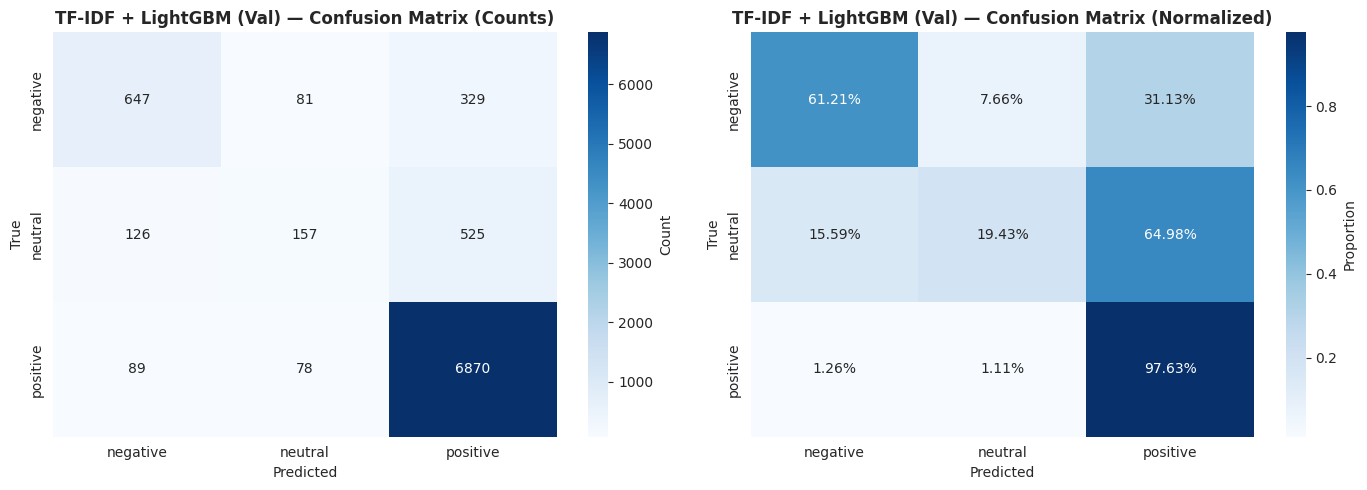

In [12]:
print("Predicting on validation set...")
start = time.time()
y_val_pred_lgb_proba = lgb_model.predict(X_val_tfidf)
y_val_pred_lgb = np.argmax(y_val_pred_lgb_proba, axis=1)
val_inference_time = (time.time() - start) / len(y_val) * 1000

results_lgb_val = evaluate_model(
    y_val, y_val_pred_lgb, label_encoder,
    model_name="TF-IDF + LightGBM (Validation)",
    inference_time_ms=val_inference_time,
    category_array=val_df['category'].values
)

plot_confusion_matrix(
    y_val, y_val_pred_lgb, label_encoder,
    model_name="TF-IDF + LightGBM (Val)",
    save_path="../reports/figures/07_lgb_confusion_val.png"
)

Predicting on test set...

  TF-IDF + LightGBM (Test)
Accuracy:    0.8544
F1 (macro):  0.6158  (primary metric)
F1 (weighted): 0.8325
Inference:   0.02 ms/sample

Per-class breakdown:
Class        Precision    Recall       F1          
------------------------------------------------
negative     0.7267       0.5686       0.6380      
neutral      0.5249       0.1953       0.2847      
positive     0.8808       0.9731       0.9247      

Per-category macro F1:
  Beauty         : 0.6010
  Books          : 0.5789
  Electronics    : 0.6218
Saved: ../reports/figures/08_lgb_confusion_test.png


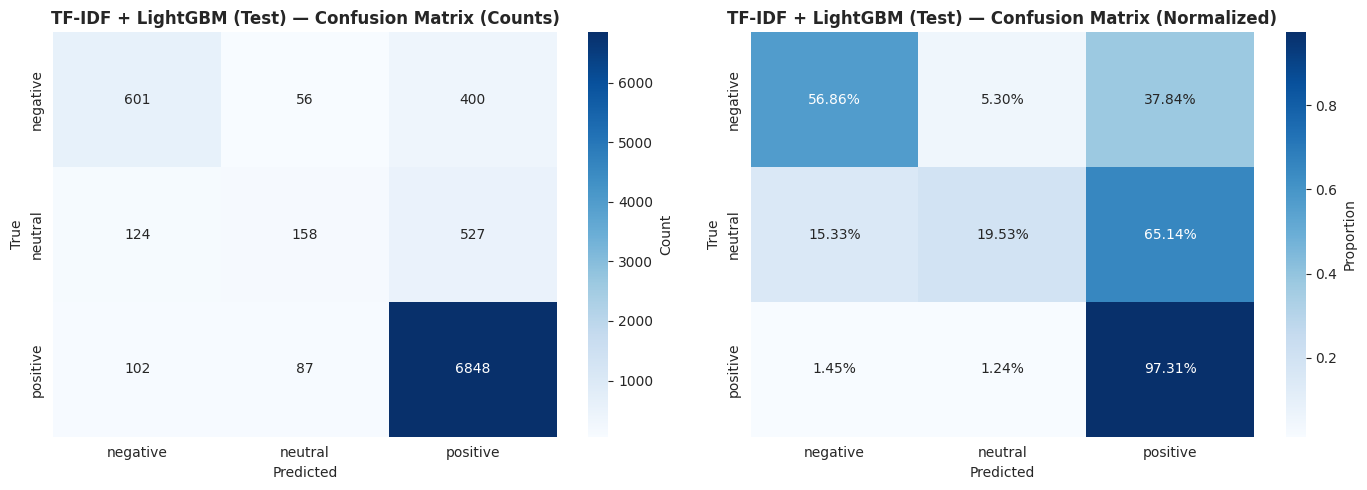

In [13]:
print("Predicting on test set...")
start = time.time()
y_test_pred_lgb_proba = lgb_model.predict(X_test_tfidf)
y_test_pred_lgb = np.argmax(y_test_pred_lgb_proba, axis=1)
test_inference_time = (time.time() - start) / len(y_test) * 1000

results_lgb_test = evaluate_model(
    y_test, y_test_pred_lgb, label_encoder,
    model_name="TF-IDF + LightGBM (Test)",
    inference_time_ms=test_inference_time,
    category_array=test_df['category'].values
)

plot_confusion_matrix(
    y_test, y_test_pred_lgb, label_encoder,
    model_name="TF-IDF + LightGBM (Test)",
    save_path="../reports/figures/08_lgb_confusion_test.png"
)

In [16]:
comparison_data = []
for results in [results_lr_test, results_lgb_test]:
    row = {
        'Model': results['model_name'].replace(' (Test)', ''),
        'Accuracy': f"{results['accuracy']:.4f}",
        'F1 (macro)': f"{results['f1_macro']:.4f}",
        'F1 (weighted)': f"{results['f1_weighted']:.4f}",
        'F1 (negative)': f"{results['f1_per_class']['negative']:.4f}",
        'F1 (neutral)': f"{results['f1_per_class']['neutral']:.4f}",
        'F1 (positive)': f"{results['f1_per_class']['positive']:.4f}",
        'Inference (ms)': f"{results['inference_time_ms']:.2f}"
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("BASELINE MODELS — TEST SET COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

comparison_md = comparison_df.to_markdown(index=False)
print("\nMarkdown version (for README):\n")
print(comparison_md)


BASELINE MODELS — TEST SET COMPARISON
                       Model Accuracy F1 (macro) F1 (weighted) F1 (negative) F1 (neutral) F1 (positive) Inference (ms)
TF-IDF + Logistic Regression   0.8523     0.6555        0.8483        0.6695       0.3665        0.9306           0.00
           TF-IDF + LightGBM   0.8544     0.6158        0.8325        0.6380       0.2847        0.9247           0.02

Markdown version (for README):

| Model                        |   Accuracy |   F1 (macro) |   F1 (weighted) |   F1 (negative) |   F1 (neutral) |   F1 (positive) |   Inference (ms) |
|:-----------------------------|-----------:|-------------:|----------------:|----------------:|---------------:|----------------:|-----------------:|
| TF-IDF + Logistic Regression |     0.8523 |       0.6555 |          0.8483 |          0.6695 |         0.3665 |          0.9306 |             0    |
| TF-IDF + LightGBM            |     0.8544 |       0.6158 |          0.8325 |          0.638  |         0.2847 |     

In [17]:
results_dir = Path("../reports")
results_dir.mkdir(parents=True, exist_ok=True)

all_results = {
    'logistic_regression': {
        'val': results_lr_val,
        'test': results_lr_test
    },
    'lightgbm': {
        'val': results_lgb_val,
        'test': results_lgb_test
    }
}

with open(results_dir / "baseline_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved: {results_dir / 'baseline_results.json'}")

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

with open(models_dir / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open(models_dir / "logreg_baseline.pkl", "wb") as f:
    pickle.dump(logreg, f)

lgb_model.save_model(str(models_dir / "lightgbm_baseline.txt"))

with open(models_dir / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print(f"\nModels saved to: {models_dir}/")
print("Files:")
for f in models_dir.glob("*"):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}: {size_kb:.1f} KB")

Results saved: ../reports/baseline_results.json

Models saved to: ../models/
Files:
  lightgbm_baseline.txt: 3926.6 KB
  tfidf_vectorizer.pkl: 25969.3 KB
  .gitkeep: 0.0 KB
  logreg_baseline.pkl: 1172.6 KB
  label_encoder.pkl: 0.3 KB


In [18]:
print("="*60)
print("BASELINE MODELING COMPLETE")
print("="*60)

# Determine winner
lr_f1 = results_lr_test['f1_macro']
lgb_f1 = results_lgb_test['f1_macro']

print(f"\nFinal Test Set Performance:")
print(f"  Logistic Regression: {lr_f1:.4f} macro F1")
print(f"  LightGBM:            {lgb_f1:.4f} macro F1")

if lgb_f1 > lr_f1:
    diff = (lgb_f1 - lr_f1) * 100
    print(f"\n→ LightGBM wins by {diff:.2f} percentage points")
else:
    diff = (lr_f1 - lgb_f1) * 100
    print(f"\n→ Logistic Regression wins by {diff:.2f} percentage points")

print(f"\nNext step: DistilBERT fine-tuning (notebook 04)")
print(f"   Goal: see if deep learning can beat ~0.{int(max(lr_f1, lgb_f1)*10000):04d} macro F1")

BASELINE MODELING COMPLETE

Final Test Set Performance:
  Logistic Regression: 0.6555 macro F1
  LightGBM:            0.6158 macro F1

→ Logistic Regression wins by 3.98 percentage points

Next step: DistilBERT fine-tuning (notebook 04)
   Goal: see if deep learning can beat ~0.6555 macro F1


In [19]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_tfidf, y_train)
y_test_pred_dummy = dummy.predict(X_test_tfidf)

results_dummy = evaluate_model(
    y_test, y_test_pred_dummy, label_encoder,
    model_name="Dummy (Always Positive) — Sanity Check"
)


  Dummy (Always Positive) — Sanity Check
Accuracy:    0.7904
F1 (macro):  0.2943  (primary metric)
F1 (weighted): 0.6979

Per-class breakdown:
Class        Precision    Recall       F1          
------------------------------------------------
negative     0.0000       0.0000       0.0000      
neutral      0.0000       0.0000       0.0000      
positive     0.7904       1.0000       0.8829      
